## B1–B3: Trial classification, MI, and gain model

For each stimulus type, we extract trial-aligned neural responses and running speed. Trials are classified as running, still, or ignored based on running speed.

Running modulation is quantified for each neuron using:

$$
MI = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}{R_{\mathrm{run}} + R_{\mathrm{still}}}
$$

where $R_{\mathrm{run}}$ and $R_{\mathrm{still}}$ are the mean neural responses during running and still trials.

We also fit a condition-level gain model:

$$
R_{\mathrm{run}} = a R_{\mathrm{still}} + b
$$

Importantly, this model is fit across stimulus conditions, not from one overall running/still response pair. Each condition provides one point $(R_{\mathrm{still}}, R_{\mathrm{run}})$.

Condition definitions:

- **Drifting gratings:** orientation $\times$ temporal frequency
- **Static gratings:** orientation $\times$ spatial frequency $\times$ phase
- **Natural scenes:** image identity / frame number
- **Spontaneous:** no stimulus identity, so gain model is not defined

In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    spearmanr,
    wilcoxon,
    friedmanchisquare,
)

from utils import (
    load_data,
    extract_trials,
    BinaryModulation,
    # make_kfold_splits,
    # plot_grouped_distribution,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
data = load_data("data")
RESPONSE_WINDOWS = {
    "drifting_gratings": (10, 60),
    "static_gratings": (5, 7),
    "natural_scenes": (5, 7),
    "spontaneous": (0, 60),
}
print("Matched cells:", len(data["matched_cell_ids"]))

Matched cells: 47


In [17]:
results = {}

for stimulus, response_window in RESPONSE_WINDOWS.items():
    trial_data = extract_trials(
        data=data,
        stimulus=stimulus,
        response_window=response_window,
    )

    analysis = BinaryModulation(trial_data)

    analysis.classify_trials()
    analysis.compute_mi()
    analysis.fit_gain_model(min_trials_per_state=2)

    results[stimulus] = analysis

    print(f"\n{stimulus}")
    print("-" * len(stimulus))
    print("Response shape:", trial_data.responses.shape)
    print("Speed shape:", trial_data.running_speed.shape)
    print("Running trials:", int(analysis.run_mask.sum()))
    print("Still trials:", int(analysis.still_mask.sum()))
    print("Ignored trials:", int(analysis.ignored_mask.sum()))
    print("Median MI:", np.nanmedian(analysis.mi))
    print(
        "Valid gain fits:",
        int(np.isfinite(analysis.gain_a).sum()),
    )


drifting_gratings
-----------------
Response shape: (47, 598, 60)
Speed shape: (598, 60)
Running trials: 195
Still trials: 28
Ignored trials: 375
Median MI: 0.1251991242170334
Valid gain fits: 47

static_gratings
---------------
Response shape: (47, 5811, 7)
Speed shape: (5811, 7)
Running trials: 1825
Still trials: 2722
Ignored trials: 1264
Median MI: 0.02673894353210926
Valid gain fits: 47

natural_scenes
--------------
Response shape: (47, 5900, 7)
Speed shape: (5900, 7)
Running trials: 1315
Still trials: 2997
Ignored trials: 1588
Median MI: 0.2440885305404663
Valid gain fits: 47

spontaneous
-----------
Response shape: (47, 296, 60)
Speed shape: (296, 60)
Running trials: 44
Still trials: 26
Ignored trials: 226
Median MI: -0.1992952823638916
Valid gain fits: 0


## B5–B6: MI distributions and robust cross-stimulus comparison

We first visualized the raw MI distribution for each stimulus class. The raw MI showed stimulus-dependent differences, with natural scenes having the largest positive median MI and spontaneous activity showing a negative median MI. However, some cells showed extreme MI values, especially in drifting gratings and spontaneous activity.

These extreme values were caused by near-zero denominators in the MI calculation. When $(R_{\mathrm{run}} + R_{\mathrm{still}})$ is very small, even a small response difference can produce an artificially large MI.

Therefore, for the main comparison, we used a robust MI analysis excluding cells with:

$$
|R_{\mathrm{run}} + R_{\mathrm{still}}| < 10^{-3}
$$

After robust filtering, natural scenes showed the strongest positive median MI, followed by drifting gratings and static gratings. Spontaneous activity remained negatively modulated. The denominator-free response difference $(\Delta R = R_{\mathrm{run}} - R_{\mathrm{still}})$ showed the same direction, supporting that the result is not purely driven by MI denominator instability.

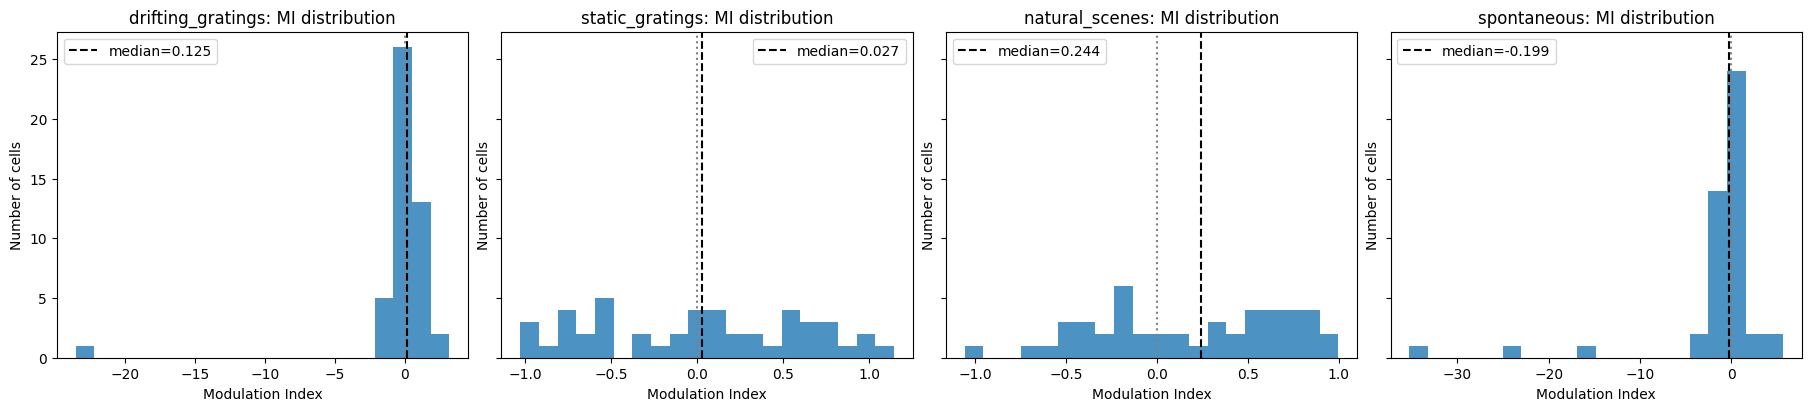

In [33]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4),
    sharey=True,
    constrained_layout=True,
)

for ax, stimulus in zip(axes, RESPONSE_WINDOWS):
    results[stimulus].plot_mi_histogram(ax=ax)

plt.show()

In [34]:
DENOM_THRESHOLD = 1e-3

def get_robust_mi(analysis, denom_threshold=DENOM_THRESHOLD):
    """Return raw MI and a robust-cell mask for one BinaryModulation result."""
    mi = analysis.mi
    denom = analysis.r_run + analysis.r_still

    robust = (
        np.isfinite(mi)
        & np.isfinite(denom)
        & (np.abs(denom) > denom_threshold)
    )

    return mi, robust

In [35]:
summary = []

for stim, bm in results.items():
    mi, robust = get_robust_mi(bm)

    finite = np.isfinite(mi)
    delta = bm.r_run - bm.r_still

    summary.append({
        "stimulus": stim,
        "n_cells": len(mi),
        "n_robust": int(robust.sum()),
        "n_excluded": int(finite.sum() - robust.sum()),
        "median_MI_raw": float(np.nanmedian(mi[finite])),
        "median_MI_robust": float(np.nanmedian(mi[robust])),
        "median_delta_R": float(np.nanmedian(delta[robust])),
        "frac_positive_MI_robust": float(np.mean(mi[robust] > 0)),
    })

summary_df = pd.DataFrame(summary)
summary_df

,stimulus,n_cells,n_robust,n_excluded,median_MI_raw,median_MI_robust,median_delta_R,frac_positive_MI_robust
0,drifting_gratings,47,42,5,0.125199,0.213670,0.000783,0.619048
1,static_gratings,47,45,2,0.026739,0.105181,0.000226,0.555556
2,natural_scenes,47,47,0,0.244089,0.244089,0.001423,0.574468
3,spontaneous,47,35,12,-0.199295,-0.156534,-0.001170,0.457143


Inspection of the extreme MI values showed that they were caused by near-zero denominators, where $R_{\mathrm{run}} + R_{\mathrm{still}}$ was very small. In these cases, even a small response difference can produce an artificially large MI value. Therefore, these extreme values are better interpreted as numerical instability rather than strong biological modulation. In that case, we introduce robust MI value.

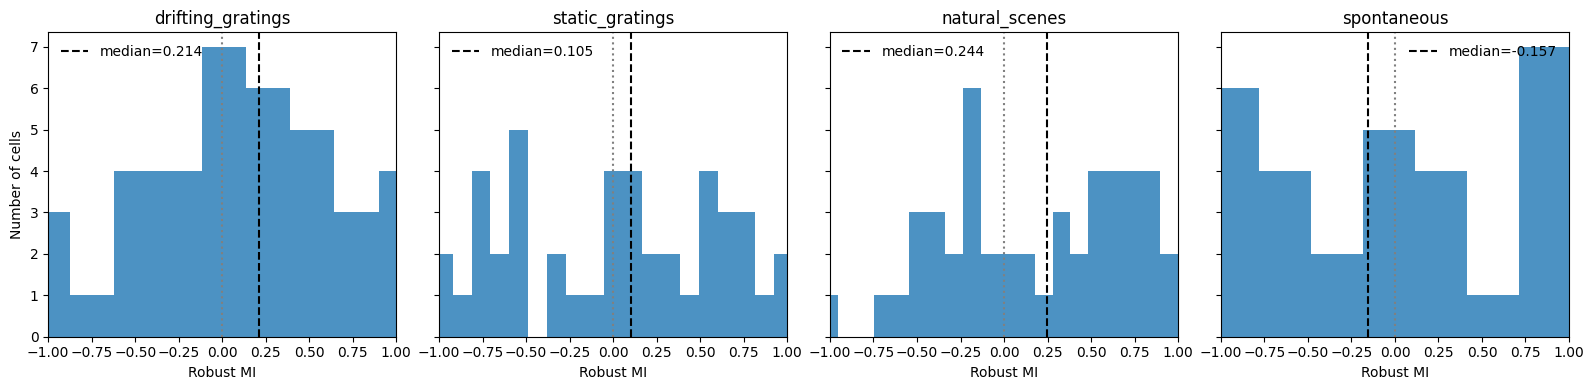

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, stim in zip(axes, results.keys()):
    bm = results[stim]
    mi = bm.mi
    denom = bm.r_run + bm.r_still

    robust = np.isfinite(mi) & (np.abs(denom) > 1e-3)
    mi_robust = mi[robust]
    median_mi = np.nanmedian(mi_robust)

    ax.hist(mi_robust, bins=20, alpha=0.8)
    ax.axvline(
        median_mi,
        linestyle="--",
        color="black",
        label=f"median={median_mi:.3f}",
    )
    ax.axvline(0, linestyle=":", color="gray")

    ax.set_xlim(-1, 1)
    ax.set_title(stim)
    ax.set_xlabel("Robust MI")
    ax.legend(frameon=False)   

axes[0].set_ylabel("Number of cells")
plt.tight_layout()
plt.show()

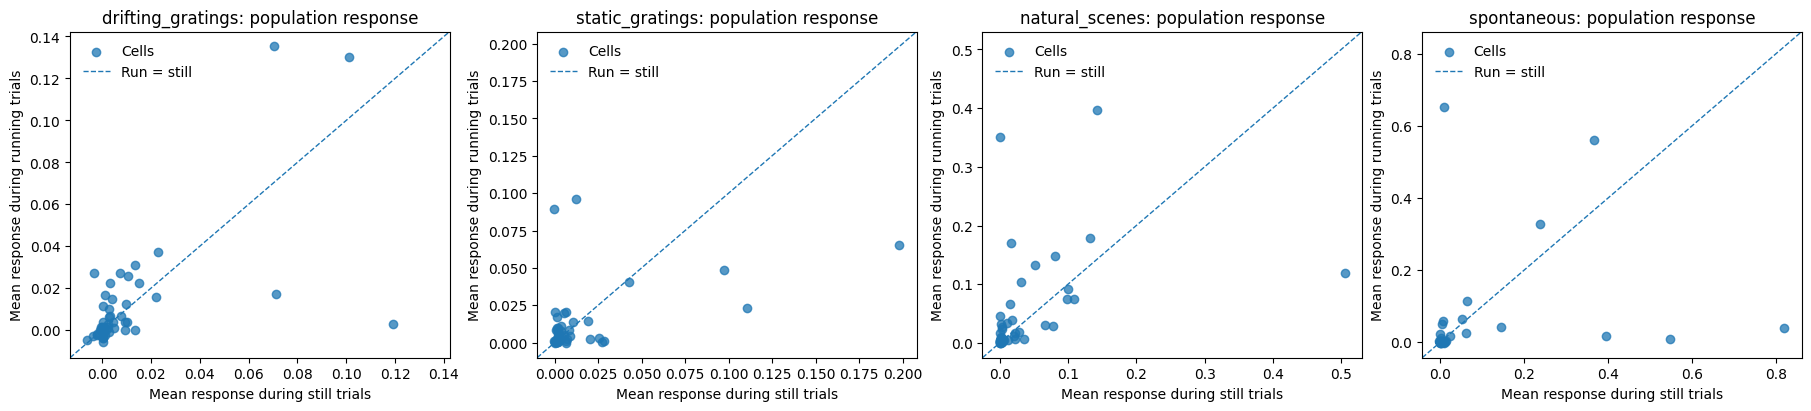

In [37]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4),
    constrained_layout=True,
)

for ax, stimulus in zip(axes, RESPONSE_WINDOWS):
    results[stimulus].plot_scatter(
        cell=None,
        ax=ax,
    )

plt.show()

Each point represents one neuron. The x-axis shows the mean response during still trials, and the y-axis shows the mean response during running trials. The dashed line indicates equal responses during running and still states.

Points above the dashed line indicate positive running modulation, while points below the dashed line indicate negative modulation. Consistent with the MI results, visually evoked responses tend to show positive running modulation, especially for natural scenes. Spontaneous activity shows a more mixed pattern and includes several cells with lower running responses than still responses.

Eligible cells: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


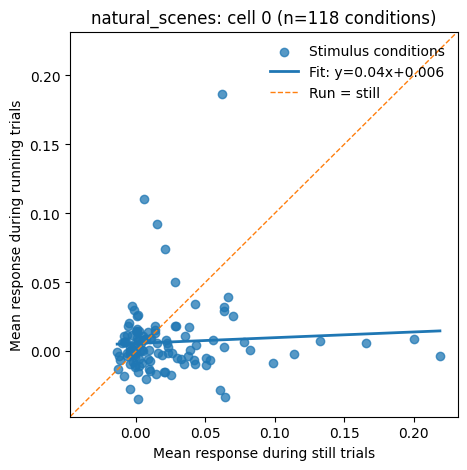

Cell: 0
Gain slope a: 0.041256431976834776
Offset b: 0.005818640464757447
Fit R²: 0.003870053014418562
Number of conditions: 118


In [38]:
stimulus = "natural_scenes"
analysis = results[stimulus]

eligible_cells = np.where(
    analysis.n_gain_conditions >= 10
)[0]

print("Eligible cells:", eligible_cells)

if eligible_cells.size > 0:
    cell = int(eligible_cells[0])

    fig = analysis.plot_scatter(cell=cell)
    plt.show()

    print("Cell:", cell)
    print("Gain slope a:", analysis.gain_a[cell])
    print("Offset b:", analysis.gain_b[cell])
    print("Fit R²:", analysis.gain_r2[cell])
    print(
        "Number of conditions:",
        analysis.n_gain_conditions[cell],
    )
else:
    print("No cell has at least 10 valid conditions.")

In [39]:
gain_rows = []

for stimulus, bm in results.items():
    if stimulus == "spontaneous":
        continue

    valid = (
        np.isfinite(bm.gain_a)
        & np.isfinite(bm.gain_b)
    )

    gain_rows.append({
        "stimulus": stimulus,
        "n_valid_gain_fits": int(valid.sum()),
        "median_gain_a": float(np.nanmedian(bm.gain_a[valid])),
        "median_gain_b": float(np.nanmedian(bm.gain_b[valid])),
        "median_gain_r2": float(np.nanmedian(bm.gain_r2[valid])),
        "median_n_conditions": float(np.nanmedian(bm.n_gain_conditions[valid])),
        "frac_gain_a_gt_1": float(np.mean(bm.gain_a[valid] > 1)),
    })

gain_summary = pd.DataFrame(gain_rows)
gain_summary

,stimulus,n_valid_gain_fits,median_gain_a,median_gain_b,median_gain_r2,median_n_conditions,frac_gain_a_gt_1
0,drifting_gratings,47,0.109210,0.001252,0.107586,6.0,0.085106
1,static_gratings,47,0.273037,0.002341,0.053763,120.0,0.085106
2,natural_scenes,47,0.452296,0.009118,0.047038,118.0,0.234043


The single-cell condition-level plot illustrates how the gain model is fit across stimulus conditions. For natural scenes, each image identity contributes one $((R_{\mathrm{still}}, R_{\mathrm{run}}))$ point. In the example cell shown here, the fitted slope is low, indicating that running-related modulation is not simply a strong multiplicative scaling of the still response pattern for this neuron.

## B7: Validation against Allen metadata

To validate our computed modulation index, we compared each neuron's MI with the pre-computed Allen running modulation metrics in `neurons_metadata.csv`.

We validated the three visually evoked stimulus classes:

- drifting gratings: `run_mod_dg`
- static gratings: `run_mod_sg`
- natural scenes: `run_mod_ns`

We used Spearman correlation because the MI distributions contain outliers and may not be normally distributed. For consistency with the main analysis, we used robust MI values after excluding cells with near-zero denominators.

In [25]:
metadata = pd.read_csv("data/neurons_metadata.csv")

print(metadata.shape)
metadata.head()
matched_ids = data["matched_cell_ids"]

meta = (
    metadata
    .set_index("cell_specimen_id")
    .loc[matched_ids]
)

print(meta.shape)
meta[["run_mod_dg", "run_mod_sg", "run_mod_ns"]].head()

(47, 61)
(47, 60)


,run_mod_dg,run_mod_sg,run_mod_ns
cell_specimen_id,,,
517423581,-1.600696,-0.180092,-0.903219
517423604,1.132572,-0.110244,0.829786
517423621,0.225011,0.928413,0.959424
517423644,-0.706339,0.669125,-0.052490
517423693,-0.814703,0.221538,0.890476


In [ ]:
validation_rows = []

mapping = {
    "drifting_gratings": "run_mod_dg",
    "static_gratings": "run_mod_sg",
    "natural_scenes": "run_mod_ns",
}

for stimulus, meta_col in mapping.items():
    bm = results[stimulus]

    mi, robust = get_robust_mi(bm)
    ref = meta[meta_col].to_numpy()

    valid = (
        robust
        & np.isfinite(mi)
        & np.isfinite(ref)
    )

    rho, pval = spearmanr(
        mi[valid],
        ref[valid],
    )

    validation_rows.append({
        "stimulus": stimulus,
        "metadata_col": meta_col,
        "n_cells": int(valid.sum()),
        "spearman_rho": float(rho),
        "p_value": float(pval),
        "median_our_MI": float(np.nanmedian(mi[valid])),
        "median_metadata_run_mod": float(np.nanmedian(ref[valid])),
    })

validation_df = pd.DataFrame(validation_rows)
validation_df

,stimulus,metadata_col,n_cells,spearman_rho,p_value,median_our_MI,median_metadata_run_mod
0,drifting_gratings,run_mod_dg,42,0.132809,4.017772e-01,0.213670,0.329294
1,static_gratings,run_mod_sg,45,0.746377,3.966221e-09,0.105181,0.223448
2,natural_scenes,run_mod_ns,47,0.697155,5.205690e-08,0.244089,0.363075


Drifting gratings showed only a weak and non-significant correlation with the Allen `run_mod_dg` metric. We therefore treat this as a divergence from the metadata validation, possibly due to the small number of still trials, response-window differences, or differences in running-state definitions.

In [27]:
validation_rows_raw = []

mapping = {
    "drifting_gratings": "run_mod_dg",
    "static_gratings": "run_mod_sg",
    "natural_scenes": "run_mod_ns",
}

for stimulus, meta_col in mapping.items():
    bm = results[stimulus]

    mi = bm.mi
    ref = meta[meta_col].to_numpy()

    valid = (
        np.isfinite(mi)
        & np.isfinite(ref)
    )

    rho, pval = spearmanr(
        mi[valid],
        ref[valid],
    )

    validation_rows_raw.append({
        "stimulus": stimulus,
        "metadata_col": meta_col,
        "n_cells": int(valid.sum()),
        "spearman_rho_raw": float(rho),
        "p_value_raw": float(pval),
        "median_MI_raw": float(np.nanmedian(mi[valid])),
        "median_metadata_run_mod": float(np.nanmedian(ref[valid])),
    })

validation_raw_df = pd.DataFrame(validation_rows_raw)
validation_raw_df

,stimulus,metadata_col,n_cells,spearman_rho_raw,p_value_raw,median_MI_raw,median_metadata_run_mod
0,drifting_gratings,run_mod_dg,47,0.161887,2.769716e-01,0.125199,0.225011
1,static_gratings,run_mod_sg,47,0.664084,3.599877e-07,0.026739,0.288290
2,natural_scenes,run_mod_ns,47,0.697155,5.205690e-08,0.244089,0.363075


We also repeated the metadata validation using raw MI values without denominator-based filtering. The overall patternwas unchanged. Static gratings and natural scenes remained strongly and significantly correlated with the Allen running-modulation metrics, while drifting gratings remained weak and non-significant.

This suggests that the main validation result is not an artifact of the robust MI filter. The divergence for drifting gratings likely reflects stimulus-specific differences such as fewer still trials, response-window differences, behavioral-state definition, or differences between our MI and the Allen pre-computed metric.

## B6: Gratings versus natural scenes

The main project question is whether locomotion modulates neural responses differently for gratings and natural scenes.

We keep each stimulus class separate during trial extraction and MI computation. For the final comparison, we summarize grating modulation at the cell level by averaging each neuron's robust MI across drifting and static gratings:

$$
MI_{\mathrm{grating}} = \frac{MI_{\mathrm{DG}} + MI_{\mathrm{SG}}}{2}
$$

We then compare this paired grating MI against the natural-scenes MI for the same matched neurons using a Wilcoxon signed-rank test.

In [40]:
mi_dg, robust_dg = get_robust_mi(results["drifting_gratings"])
mi_sg, robust_sg = get_robust_mi(results["static_gratings"])
mi_ns, robust_ns = get_robust_mi(results["natural_scenes"])
mi_sp, robust_sp = get_robust_mi(results["spontaneous"])

mi_grating = np.nanmean(
    np.vstack([mi_dg, mi_sg]),
    axis=0,
)

robust_grating = (
    robust_dg
    & robust_sg
    & np.isfinite(mi_grating)
)

from scipy.stats import wilcoxon

valid = (
    robust_grating
    & robust_ns
    & np.isfinite(mi_grating)
    & np.isfinite(mi_ns)
)

grating_values = mi_grating[valid]
natural_values = mi_ns[valid]

stat, p = wilcoxon(
    grating_values,
    natural_values,
)

b6_result = pd.DataFrame([{
    "comparison": "gratings_vs_natural_scenes",
    "n_cells": int(valid.sum()),
    "median_grating_MI": float(np.nanmedian(grating_values)),
    "median_natural_scene_MI": float(np.nanmedian(natural_values)),
    "median_difference_NS_minus_grating": float(np.nanmedian(natural_values - grating_values)),
    "wilcoxon_stat": float(stat),
    "p_value": float(p),
    "frac_NS_greater_than_grating": float(np.mean(natural_values > grating_values)),
}])

b6_result

,comparison,n_cells,median_grating_MI,median_natural_scene_MI,median_difference_NS_minus_grating,wilcoxon_stat,p_value,frac_NS_greater_than_grating
0,gratings_vs_natural_scenes,41,0.206811,0.290377,0.138758,363.0,0.389209,0.536585


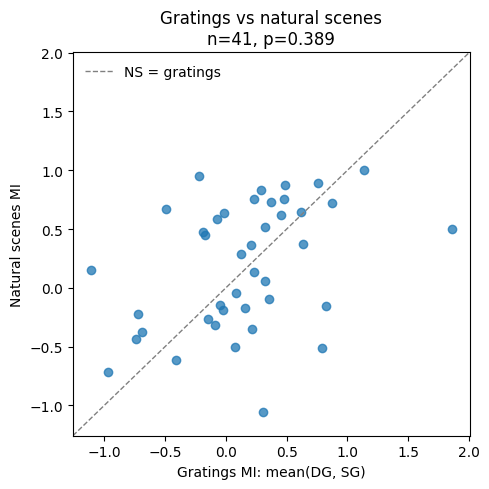

In [41]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    grating_values,
    natural_values,
    alpha=0.75,
)

lower = min(np.min(grating_values), np.min(natural_values))
upper = max(np.max(grating_values), np.max(natural_values))
margin = 0.05 * max(upper - lower, 1e-3)

lower -= margin
upper += margin

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1,
    color="gray",
    label="NS = gratings",
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)

ax.set_xlabel("Gratings MI: mean(DG, SG)")
ax.set_ylabel("Natural scenes MI")
ax.set_title(
    f"Gratings vs natural scenes\n"
    f"n={valid.sum()}, p={p:.3g}"
)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

C:\Users\hzzzz\AppData\Local\Temp\ipykernel_91028\2468699821.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


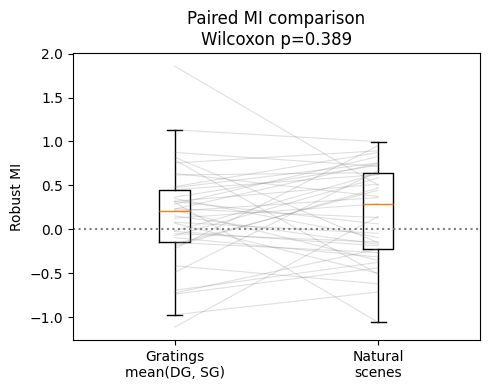

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.boxplot(
    [grating_values, natural_values],
    labels=["Gratings\nmean(DG, SG)", "Natural\nscenes"],
    showfliers=False,
)

for g, n in zip(grating_values, natural_values):
    ax.plot(
        [1, 2],
        [g, n],
        color="gray",
        alpha=0.25,
        linewidth=0.8,
    )

ax.axhline(0, linestyle=":", color="gray")
ax.set_ylabel("Robust MI")
ax.set_title(f"Paired MI comparison\nWilcoxon p={p:.3g}")

plt.tight_layout()
plt.show()